In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Aplicar estilo profesional
plt.style.use('seaborn-v0_8')  # O 'default', 'classic', 'bmh', etc.

# Configuración global de parámetros
mpl.rcParams.update({
    'font.size': 12,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 18,
    'figure.figsize': (10, 6),  # Tamaño por defecto
    'figure.dpi': 100,          # Resolución
    'savefig.dpi': 300,         # Resolución para guardar
    'savefig.bbox': 'tight',    # Recortar espacios en blanco
    'axes.grid': True,          # Cuadrícula por defecto
    'grid.alpha': 0.3,          # Transparencia de cuadrícula
})

In [2]:
# Paleta corporativa personalizada
empresa_colors = {
    'primary': '#1f77b4',      # Azul principal
    'secondary': '#ff7f0e',    # Naranja
    'accent': '#2ca02c',       # Verde
    'warning': '#d62728',      # Rojo
    'neutral': '#7f7f7f',      # Gris
}

# Función para obtener colores por categoría
def get_category_colors(categories):
    colors = plt.cm.Set3(np.linspace(0, 1, len(categories)))
    return [mpl.colors.rgb2hex(c) for c in colors]

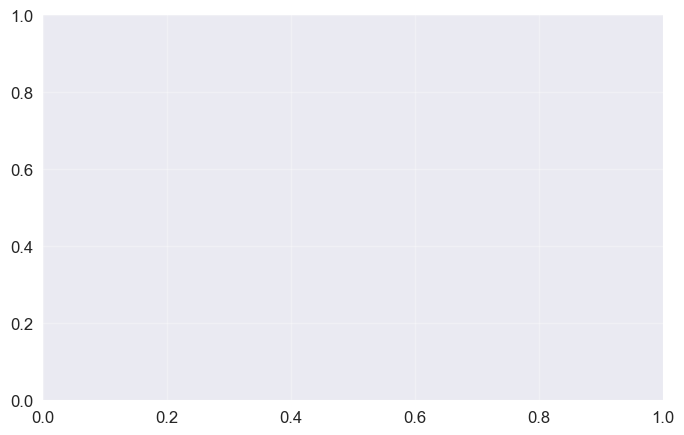

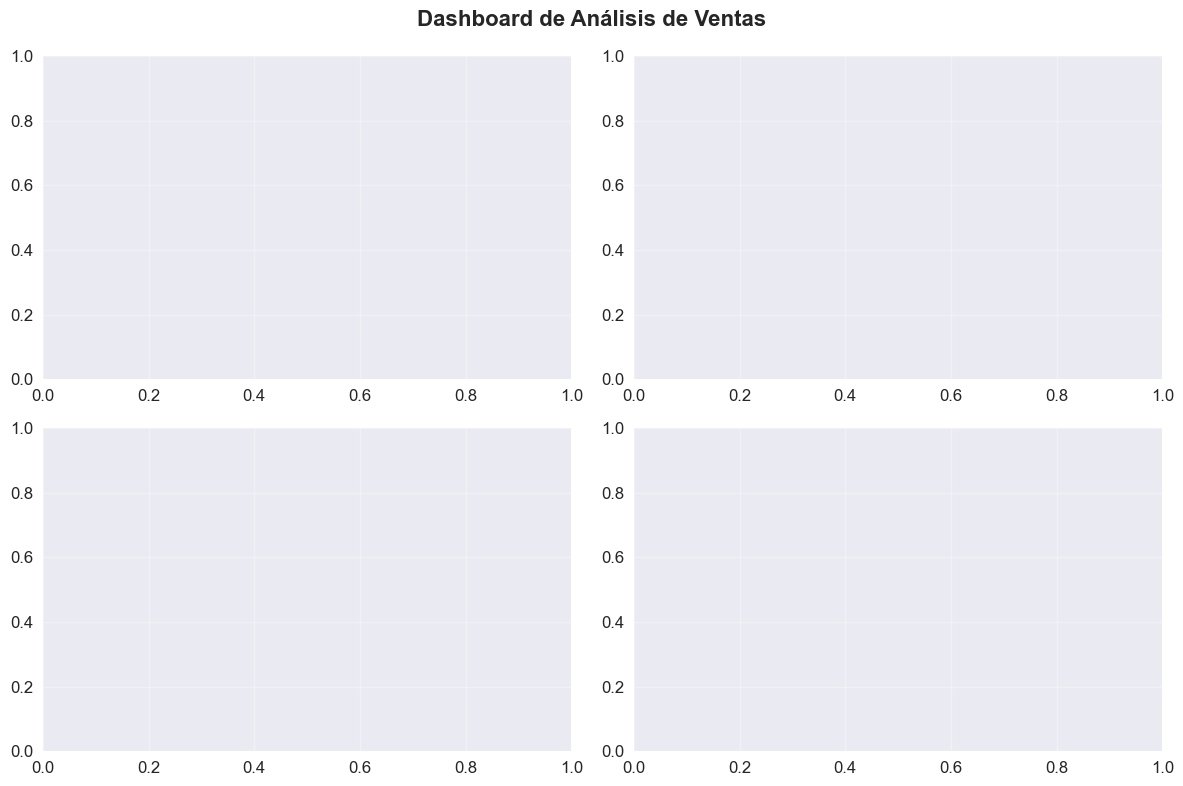

In [3]:
# Crear figura con un solo eje
fig, ax = plt.subplots(figsize=(8, 5))

# Crear figura con múltiples subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Dashboard de Análisis de Ventas', fontsize=16, fontweight='bold')

# Ajustar espaciado entre subplots
plt.tight_layout()

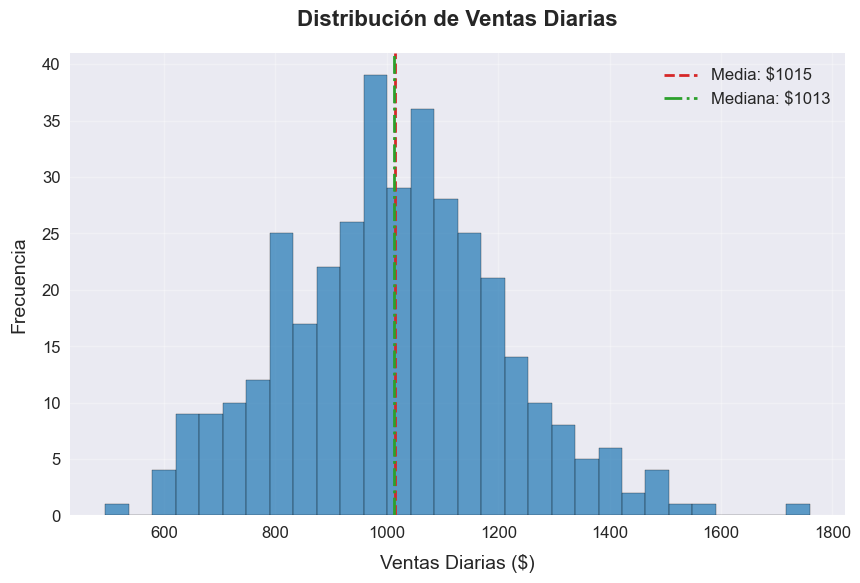

In [5]:
# Gráficos Univariados para Análisis Inicial 
import numpy as np
import matplotlib.pyplot as plt


# Datos de ejemplo
ventas_diarias = np.random.normal(1000, 200, 365)

# Histograma básico
fig, ax = plt.subplots(figsize=(10, 6))
n, bins, patches = ax.hist(ventas_diarias, bins=30, alpha=0.7, 
                          color=empresa_colors['primary'], edgecolor='black')

# Personalización profesional
ax.set_title('Distribución de Ventas Diarias', fontweight='bold', pad=20)
ax.set_xlabel('Ventas Diarias ($)', labelpad=10)
ax.set_ylabel('Frecuencia', labelpad=10)
ax.grid(True, alpha=0.3)

# Añadir estadísticos de resumen
media = np.mean(ventas_diarias)
mediana = np.median(ventas_diarias)
ax.axvline(media, color=empresa_colors['warning'], linestyle='--', 
           linewidth=2, label=f'Media: ${media:.0f}')
ax.axvline(mediana, color=empresa_colors['accent'], linestyle='-.', 
           linewidth=2, label=f'Mediana: ${mediana:.0f}')

ax.legend()
plt.savefig('histograma_ventas.png', dpi=300, bbox_inches='tight')
plt.show()

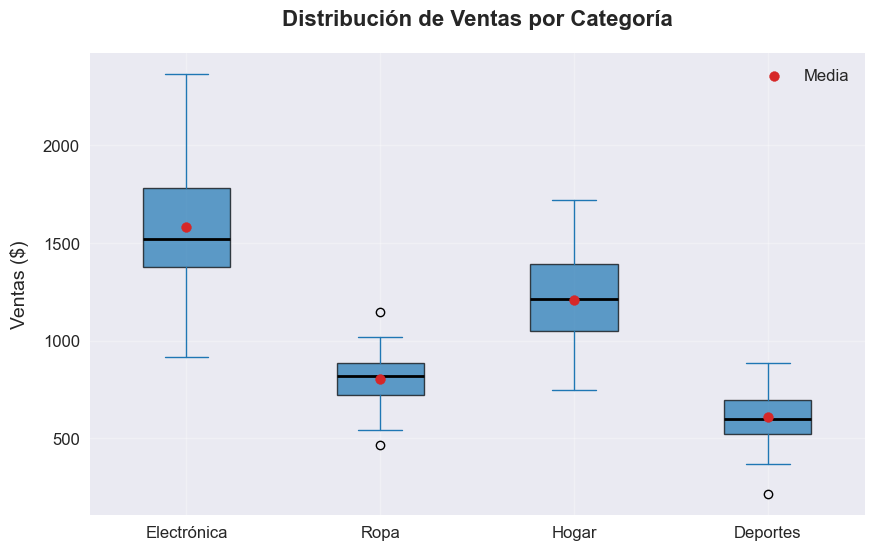

In [6]:
# Datos por categoría
ventas_por_categoria = {
    'Electrónica': np.random.normal(1500, 300, 50),
    'Ropa': np.random.normal(800, 150, 50),
    'Hogar': np.random.normal(1200, 250, 50),
    'Deportes': np.random.normal(600, 120, 50)
}

# Box plot comparativo
fig, ax = plt.subplots(figsize=(10, 6))

# Preparar datos para boxplot
data = list(ventas_por_categoria.values())
labels = list(ventas_por_categoria.keys())

bp = ax.boxplot(data, labels=labels, patch_artist=True, 
                medianprops={'color': 'black', 'linewidth': 2},
                boxprops={'facecolor': empresa_colors['primary'], 'alpha': 0.7},
                whiskerprops={'color': empresa_colors['primary']},
                capprops={'color': empresa_colors['primary']})

ax.set_title('Distribución de Ventas por Categoría', fontweight='bold', pad=20)
ax.set_ylabel('Ventas ($)', labelpad=10)
ax.grid(True, alpha=0.3, axis='y')

# Añadir valores medios como puntos
for i, categoria in enumerate(labels):
    media = np.mean(data[i])
    ax.scatter(i+1, media, color=empresa_colors['warning'], s=50, zorder=3, label='Media' if i == 0 else "")

ax.legend()
plt.savefig('boxplot_categorias.png', dpi=300, bbox_inches='tight')
plt.show()

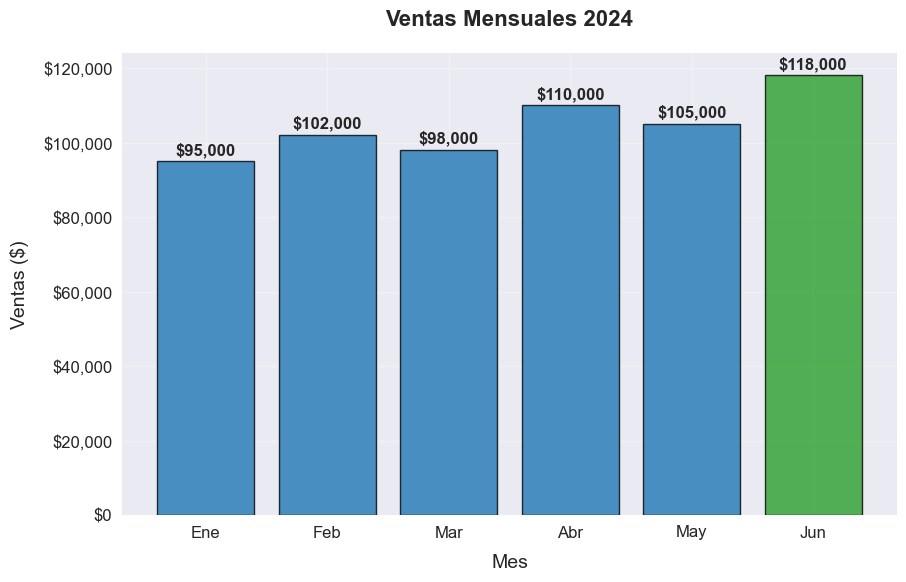

In [7]:
# Datos de ventas mensuales
meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun']
ventas_mensuales = [95000, 102000, 98000, 110000, 105000, 118000]

fig, ax = plt.subplots(figsize=(10, 6))

# Crear barras con colores diferenciados para destacar el mejor mes
colors = [empresa_colors['primary'] if v < max(ventas_mensuales) else empresa_colors['accent'] 
          for v in ventas_mensuales]

bars = ax.bar(meses, ventas_mensuales, color=colors, alpha=0.8, edgecolor='black', linewidth=1)

# Añadir valores encima de las barras
for bar, venta in zip(bars, ventas_mensuales):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1000,
            f'${venta:,}', ha='center', va='bottom', fontweight='bold')

ax.set_title('Ventas Mensuales 2024', fontweight='bold', pad=20)
ax.set_ylabel('Ventas ($)', labelpad=10)
ax.set_xlabel('Mes', labelpad=10)
ax.grid(True, alpha=0.3, axis='y')

# Formatear eje Y con separadores de miles
ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('${x:,.0f}'))

plt.savefig('barras_ventas_mensuales.png', dpi=300, bbox_inches='tight')
plt.show()

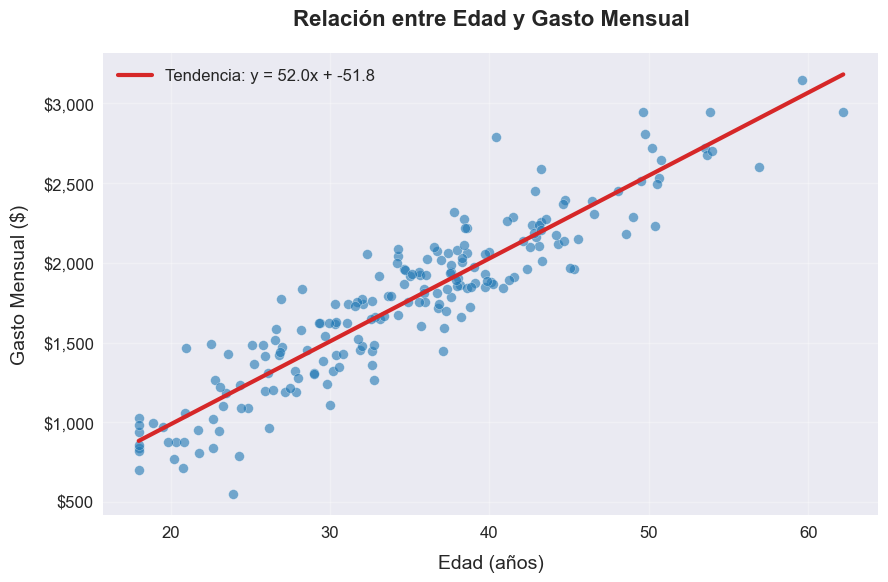

In [8]:
# Datos de clientes
np.random.seed(42)
edad = np.random.normal(35, 10, 200).clip(18, 70)
gasto_mensual = edad * 50 + np.random.normal(0, 200, 200)

fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot con ajuste lineal
ax.scatter(edad, gasto_mensual, alpha=0.6, color=empresa_colors['primary'], s=50, edgecolors='white')

# Línea de tendencia
z = np.polyfit(edad, gasto_mensual, 1)
p = np.poly1d(z)
x_trend = np.linspace(min(edad), max(edad), 100)
ax.plot(x_trend, p(x_trend), color=empresa_colors['warning'], linewidth=3, 
        label=f'Tendencia: y = {z[0]:.1f}x + {z[1]:.1f}')

ax.set_title('Relación entre Edad y Gasto Mensual', fontweight='bold', pad=20)
ax.set_xlabel('Edad (años)', labelpad=10)
ax.set_ylabel('Gasto Mensual ($)', labelpad=10)
ax.grid(True, alpha=0.3)
ax.legend()

# Formatear ejes
ax.xaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:.0f}'))
ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('${x:,.0f}'))

plt.savefig('scatter_edad_gasto.png', dpi=300, bbox_inches='tight')
plt.show()

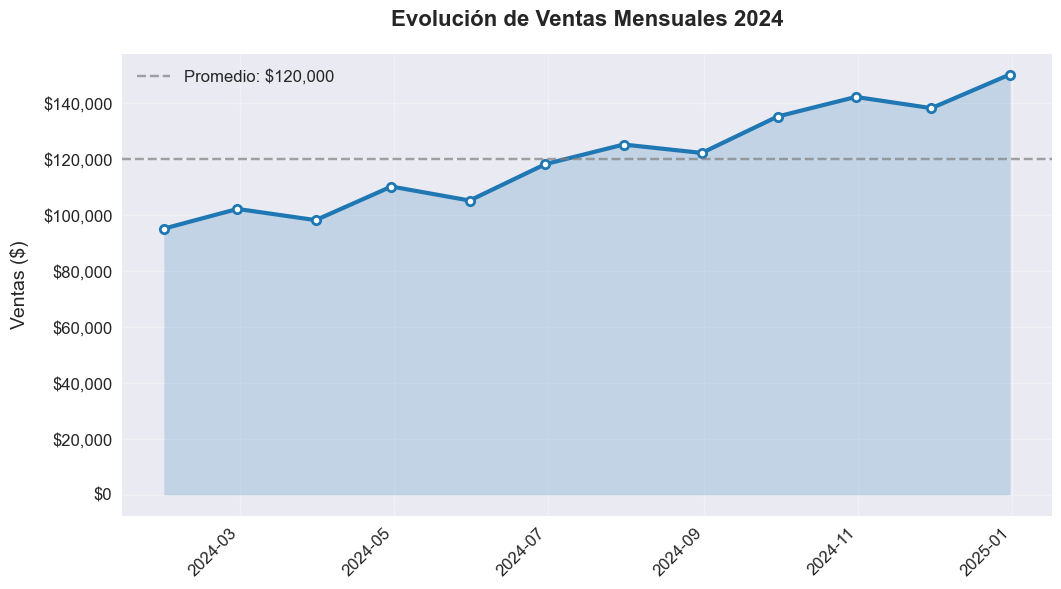

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
# Datos temporales de ventas
fechas = pd.date_range('2024-01-01', periods=12, freq='M')
ventas_mensuales = [95000, 102000, 98000, 110000, 105000, 118000, 
                   125000, 122000, 135000, 142000, 138000, 150000]

fig, ax = plt.subplots(figsize=(12, 6))

# Gráfico de línea principal
line = ax.plot(fechas, ventas_mensuales, color=empresa_colors['primary'], 
               linewidth=3, marker='o', markersize=6, markerfacecolor='white', 
               markeredgecolor=empresa_colors['primary'], markeredgewidth=2)

# Área bajo la curva para enfatizar crecimiento
ax.fill_between(fechas, ventas_mensuales, alpha=0.2, color=empresa_colors['primary'])

# Líneas de referencia
venta_promedio = np.mean(ventas_mensuales)
ax.axhline(y=venta_promedio, color=empresa_colors['neutral'], linestyle='--', alpha=0.7,
           label=f'Promedio: ${venta_promedio:,.0f}')

ax.set_title('Evolución de Ventas Mensuales 2024', fontweight='bold', pad=20)
ax.set_ylabel('Ventas ($)', labelpad=10)
ax.grid(True, alpha=0.3)
ax.legend()

# Formatear eje Y
ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('${x:,.0f}'))

# Rotar etiquetas del eje X para mejor legibilidad
plt.xticks(rotation=45, ha='right')

plt.savefig('linea_ventas_temporales.png', dpi=300, bbox_inches='tight')
plt.show()